# Emotion Text Classifier
### Building a baseline NLP classification pipeline

## Imports

In [2]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

## Load Dataset

In [3]:
DATA_PATH = Path("../data/raw/emotion_dataset")

train_path = DATA_PATH / "train.txt"
val_path = DATA_PATH / "val.txt"
test_path = DATA_PATH / "test.txt"

In [4]:
train_df = pd.read_csv(train_path, sep=";", names=["text", "emotion"])
val_df = pd.read_csv(val_path, sep=";", names=["text", "emotion"])
test_df = pd.read_csv(test_path, sep=";", names=["text", "emotion"])

## Dataset Overview
#### We inspect the dataset structure and preview a few examples

In [5]:
print("Train size:", train_df.shape)
print("Validation size:", val_df.shape)
print("Test size:", test_df.shape)

Train size: (16000, 2)
Validation size: (2000, 2)
Test size: (2000, 2)


In [6]:
train_df.head()

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


## Label Distribution
#### We analyze how the emotion classes are distributed in the training dataset

In [7]:
train_df["emotion"].value_counts()

emotion
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

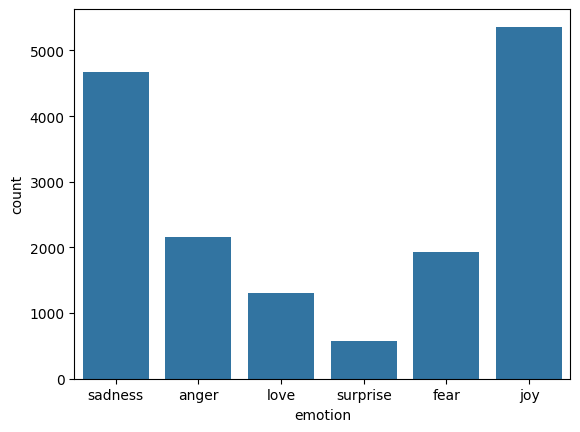

In [8]:
sns.countplot(x="emotion", data=train_df)
plt.show()

## Text Preprocessing
#### We clean and normalize the text data by lowercasing and removing non-alphabetic characters

In [9]:
def clean_text(text):
    
    text = text.lower()
    
    text = re.sub(r"[^a-z\s]", "", text)
    
    return text

In [10]:
train_df["clean_text"] = train_df["text"].apply(clean_text)
val_df["clean_text"] = val_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

In [11]:
train_df[["text", "clean_text"]].head()

,text,clean_text
0,i didnt feel humiliated,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy,i am feeling grouchy


## Define Features and Labels

In [12]:
X_train = train_df["clean_text"]
y_train = train_df["emotion"]

X_val = val_df["clean_text"]
y_val = val_df["emotion"]

X_test = test_df["clean_text"]
y_test = test_df["emotion"]

## Feature Extraction with TF-IDF
#### We convert the cleaned text into numerical feature vectors using TF-IDF

In [13]:
vectorizer = TfidfVectorizer()

In [14]:
X_train = vectorizer.fit_transform(X_train)
X_val = vectorizer.transform(X_val)
X_test = vectorizer.transform(X_test)

In [17]:
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

X_train shape: (16000, 15186)
X_val shape: (2000, 15186)
X_test shape: (2000, 15186)


In [18]:
vectorizer.get_feature_names_out()[:20]

array(['aa', 'aaaaaaand', 'aaaaand', 'aaaand', 'aac', 'aahhh', 'aaron',
       'ab', 'abandon', 'abandoned', 'abandoning', 'abandonment',
       'abated', 'abbigail', 'abc', 'abdomen', 'abdominal', 'abducted',
       'abelard', 'abhorrent'], dtype=object)

## Baseline Model: Logistic Regression
#### We train a Logistic Regression model as a baseline classifier for emotion prediction

In [19]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


In [20]:
y_val_pred = lr_model.predict(X_val)

## Model Evaluation
#### We evaluate the baseline model on the validation set using accuracy, precision, recall, and F1-score

In [21]:
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("\nClassification Report:\n")
print(classification_report(y_val, y_val_pred))

Validation Accuracy: 0.8595

Classification Report:

              precision    recall  f1-score   support

       anger       0.91      0.81      0.86       275
        fear       0.86      0.73      0.79       212
         joy       0.84      0.95      0.89       704
        love       0.88      0.62      0.73       178
     sadness       0.86      0.94      0.90       550
    surprise       0.85      0.58      0.69        81

    accuracy                           0.86      2000
   macro avg       0.87      0.77      0.81      2000
weighted avg       0.86      0.86      0.85      2000



## Confusion Matrix
#### The confusion matrix shows correct predictions and common misclassifications

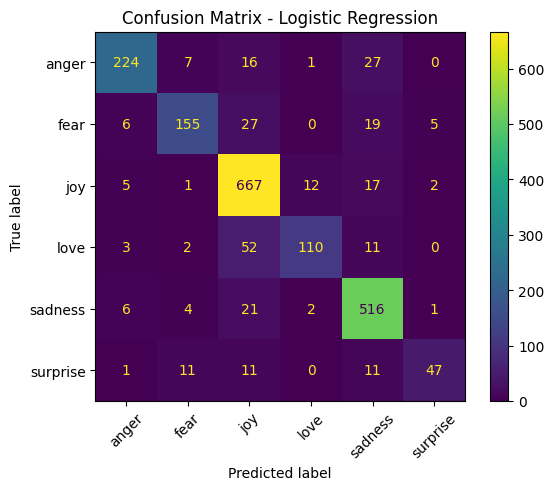

In [22]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred, xticks_rotation=45)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## Feature Importance Analysis
#### We inspect the most influential words learned by the Logistic Regression model for each emotion class based on the learned coefficients

In [23]:
feature_names = vectorizer.get_feature_names_out()
classes = lr_model.classes_

for i, class_label in enumerate(classes):
    print(f"\nTop words for class: {class_label}")
    
    top_indices = np.argsort(lr_model.coef_[i])[-5:]
    
    for idx in reversed(top_indices):
        print(f"{feature_names[idx]:<15} {lr_model.coef_[i][idx]:.4f}")


Top words for class: anger
greedy          5.6366
resentful       5.6037
offended        5.5659
dangerous       5.5487
irritable       5.5342

Top words for class: fear
terrified       6.0998
pressured       6.0419
shaken          6.0167
vulnerable      5.9091
reluctant       5.8931

Top words for class: joy
satisfied       4.0081
superior        3.9599
innocent        3.8327
successful      3.7892
pleasant        3.7692

Top words for class: love
sympathetic     6.2636
caring          6.1354
nostalgic       5.9931
longing         5.8729
naughty         5.7558

Top words for class: sadness
lethargic       4.6595
melancholy      4.6057
punished        4.3380
burdened        4.3088
missed          4.2853

Top words for class: surprise
amazed          7.9699
impressed       7.8789
curious         7.5365
surprised       7.1868
shocked         6.8023


## Model Behavior on Controlled Sentences
#### We test the model on manually written sentences containing highly weighted words to better understand its behavior

In [24]:
def predict_emotion(text):
    cleaned = clean_text(text)  
    vectorized = vectorizer.transform([cleaned])
    prediction = lr_model.predict(vectorized)
    
    return prediction[0]

In [25]:
examples = [
    "I feel very resentful and irritated today",
    "I feel terrified and vulnerable right now",
    "I feel very happy and satisfied with my life",
    "I feel sympathetic and caring towards others",
    "I feel very melancholic and burdened",
    "I am amazed and shocked by this"
]

for text in examples:
    print(text, "→", predict_emotion(text))

I feel very resentful and irritated today → anger
I feel terrified and vulnerable right now → fear
I feel very happy and satisfied with my life → joy
I feel sympathetic and caring towards others → love
I feel very melancholic and burdened → sadness
I am amazed and shocked by this → surprise
